# 02 — Regionalización de parámetros

Reparte parámetros del **SAND Nacional** entre las 7 regiones usando los archivos de
`Insumos/Mapeo/` como única fuente de configuración. Todos los parámetros pasan por la
misma lógica general — no hay secciones especiales por sector.

**Lógica** (`src/regionalizador.regionalizar_con_mapeo`):

- **Intensivos** (lista en `params_config.yaml`): se copia el valor nacional a cada región
  donde el código exista según `mapeo_tech_fuel.xlsx` (o a las 7 si no hay mapeo).
- **Aditivos**: `valor_regional = valor_nacional × participación`. Los centinelas
  (99999 / solo-9s) se copian sin repartir.
- **Condicionales** (`TotalAnnualMaxCapacityInvestment`, `TotalTechnologyAnnualActivityUpperLimit`,
  `TotalTechnologyModelPeriodActivityUpperLimit`): se resuelven **fila a fila** — si la fila
  nacional es toda ceros o solo-9s se copia (intensivo); si trae valores reales se reparte.
- Los renombramientos del mapeo se aplican al prefijar: si `ELC` se llama `ELC003` en el
  regional, se escribe `AN_ELC003`, no `AN_ELC`.
- Las tecnologías `TRN*` (transmisión interregional) se saltan en silencio: son nuevas por
  diseño del modelo regional, no omisiones.

**Antes de repartir** (Sección 3) se detectan los casos problemáticos y se decide qué hacer
con cada uno; las decisiones quedan auditadas en `reportes/omisiones_regionalizacion.xlsx`.

Salidas: un **SAND reducido** por parámetro en `SANDs_Reducidos/` (o consolidado) y un
**log** de ejecución (Excel + texto) en `reportes/`.

> Ejecutable de principio a fin con *Run All*. Con `MODO_DRY_RUN = True` no escribe nada.

## 1. Setup y configuración de la corrida

In [1]:
# --- Setup: raíz del proyecto, módulos src/ y configuración ---
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Markdown, display

pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda v: f"{v:,.6f}")

RAIZ = Path.cwd().resolve()
if not (RAIZ / "config").exists():   # ejecutado desde notebooks/
    RAIZ = RAIZ.parent
sys.path.insert(0, str(RAIZ / "src"))

import comparador
import regionalizador
import reporte
import sand_io
import utils
import yaml_parser

utils.configurar_logging()

params_cfg = yaml_parser.cargar_params_config(RAIZ / "config" / "params_config.yaml")
paths = yaml_parser.cargar_paths_config(RAIZ / "config" / "paths_config.yaml", raiz=RAIZ)
otoole = yaml_parser.cargar_config_otoole(paths["escenario_nacional"]["config_yaml"])

print(f"Nacional : {paths['escenario_nacional']['sand'].name}")
print(f"Regional : {paths['escenario_regional']['sand'].name}")
print(f"Config otoole: {len(otoole['param'])} parámetros, {len(otoole['set'])} sets")
print(f"Intensivos: {len(params_cfg['parametros_intensivos'])} | "
      f"Condicionales: {len(regionalizador.PARAMS_CONDICIONALES)} | "
      f"Centinela: {params_cfg['valor_centinela']}")

Nacional : 01-04-2026 SAND BASE v10.xlsx
Regional : SAND_Regional_17_07_Short.xlsx
Config otoole: 53 parámetros, 11 sets
Intensivos: 16 | Condicionales: 3 | Centinela: 99999.0


In [2]:
# --- Variables configurables de la corrida ---

# Lista de parámetros, o la cadena 'todos' para tomar los del SAND nacional
# que estén definidos en config_depurado.yaml.
PARAMETROS_A_REGIONALIZAR = [
    "AccumulatedAnnualDemand",
    "TotalTechnologyAnnualActivityLowerLimit",
]

# Códigos que contengan alguno de estos textos no se regionalizan (ej. ["TRA", "RES"]).
SECTORES_A_EXCLUIR = []

MODO_DRY_RUN = True        # True  => no escribe archivos, solo muestra qué haría
MODO_INTERACTIVO = False   # True  => pausa ante cada omisión y pide decisión (Sección 3b)
                           # False => registra las omisiones y continúa sin preguntar

ANIO_MAX = 2054                              # 2055 se excluye (ver CLAUDE.md)
YEARS_FILTRO = list(range(2022, ANIO_MAX + 1))

CONSOLIDADO = False        # True => un solo SAND_Consolidado_*.xlsx
DESCRIPCION = "Mapeo"      # sufijo de los archivos de salida

CARPETA_MAPEO = RAIZ / "Insumos" / "Mapeo"
RUTA_PARTICIPACIONES = CARPETA_MAPEO / "participaciones.xlsx"   # con fallback al legado
RUTA_OMISIONES = paths["outputs"]["reportes"] / "omisiones_regionalizacion.xlsx"

print(f"Dry-run: {MODO_DRY_RUN} | Interactivo: {MODO_INTERACTIVO}")
print(f"Años   : {YEARS_FILTRO[0]}–{YEARS_FILTRO[-1]}")
print(f"Excluir: {SECTORES_A_EXCLUIR or '(nada)'}")

Dry-run: True | Interactivo: False
Años   : 2022–2054
Excluir: (nada)


## 2. Cargar SANDs y archivos de mapeo

In [3]:
df_nacional = sand_io.cargar_sand(paths["escenario_nacional"]["sand"])
df_regional = sand_io.cargar_sand(paths["escenario_regional"]["sand"])
print(f"Nacional: {len(df_nacional):,} filas | Regional: {len(df_regional):,} filas")

# 'todos' => los parámetros del SAND nacional que config_depurado.yaml conoce
if PARAMETROS_A_REGIONALIZAR == "todos":
    PARAMETROS_A_REGIONALIZAR = sorted(
        set(df_nacional["Parameter"].dropna().unique()) & set(otoole["param"]))
    print(f"PARAMETROS_A_REGIONALIZAR = 'todos' -> {len(PARAMETROS_A_REGIONALIZAR)} parámetros")
print(f"A regionalizar: {PARAMETROS_A_REGIONALIZAR}")

Nacional: 69,644 filas | Regional: 30,471 filas
A regionalizar: ['AccumulatedAnnualDemand', 'TotalTechnologyAnnualActivityLowerLimit']


In [4]:
# Participaciones. `cargar_participaciones` estandariza tanto el formato ancho nuevo
# (Parameter|TECHNOLOGY|FUEL|Año|CA..IN) como el largo/canónico antiguo, así que la
# misma llamada sirve para ambos: solo cambia el archivo.
if RUTA_PARTICIPACIONES.exists():
    ruta_pct = RUTA_PARTICIPACIONES
    print(f"Participaciones: {ruta_pct.relative_to(RAIZ)} (formato ancho de Insumos/Mapeo/)")
else:
    ruta_pct = paths["participaciones"]["archivo"]
    print(f"AVISO: no existe {RUTA_PARTICIPACIONES.name}; se usa el legado "
          f"{ruta_pct.relative_to(RAIZ)}")

df_pct = regionalizador.cargar_participaciones(
    ruta_pct,
    parametros=PARAMETROS_A_REGIONALIZAR,
    params_otoole=otoole["param"],
)
display(df_pct.head(8))

malas = regionalizador.validar_participaciones(df_pct, params_cfg["tolerancia_participacion"])
if malas.empty:
    print("OK: todas las participaciones suman ~1.0 entre regiones")
else:
    display(Markdown(f"**ALERTA: {len(malas)} grupos no suman 1.0**"))
    display(malas.head(20))

Participaciones: Insumos\Mapeo\participaciones.xlsx (formato ancho de Insumos/Mapeo/)


23:27:44 INFO    regionalizador: participaciones.xlsx: formato ancho en regiones detectado (7 columnas de región)


23:27:44 INFO    regionalizador: Participaciones cargadas: 37653 filas (163 combos)


,Parametro,TECHNOLOGY,FUEL,Region,Año,Participacion
0,AccumulatedAnnualDemand,NaN,INDCLIM,CA,2022,0.127357
1,AccumulatedAnnualDemand,NaN,INDCLIM,CA,2023,0.120218
2,AccumulatedAnnualDemand,NaN,INDCLIM,CA,2024,0.118567
3,AccumulatedAnnualDemand,NaN,INDCLIM,CA,2025,0.114574
4,AccumulatedAnnualDemand,NaN,INDCLIM,CA,2026,0.114731
5,AccumulatedAnnualDemand,NaN,INDCLIM,CA,2027,0.114983
6,AccumulatedAnnualDemand,NaN,INDCLIM,CA,2028,0.115179
7,AccumulatedAnnualDemand,NaN,INDCLIM,CA,2029,0.115440


23:27:44 WARNING regionalizador: 149 grupos de participación no suman 1.0 (tolerancia 0.001)


**ALERTA: 149 grupos no suman 1.0**

,Parametro,TECHNOLOGY,FUEL,Año,Suma_Participacion
0,TotalTechnologyAnnualActivityLowerLimit,DEMRESELCILU_INC_URB,NaN,2025,0.000000
1,TotalTechnologyAnnualActivityLowerLimit,DEMRESELCILU_INC_URB,NaN,2026,0.000000
2,TotalTechnologyAnnualActivityLowerLimit,DEMRESELCILU_INC_URB,NaN,2027,0.000000
3,TotalTechnologyAnnualActivityLowerLimit,DEMRESELCILU_INC_URB,NaN,2028,0.000000
4,TotalTechnologyAnnualActivityLowerLimit,DEMRESELCILU_INC_URB,NaN,2029,0.000000
5,TotalTechnologyAnnualActivityLowerLimit,DEMRESELCILU_INC_URB,NaN,2030,0.000000
6,TotalTechnologyAnnualActivityLowerLimit,DEMRESELCILU_INC_URB,NaN,2031,0.000000
7,TotalTechnologyAnnualActivityLowerLimit,DEMRESELCILU_INC_URB,NaN,2032,0.000000
8,TotalTechnologyAnnualActivityLowerLimit,DEMRESELCILU_INC_URB,NaN,2033,0.000000
9,TotalTechnologyAnnualActivityLowerLimit,DEMRESELCILU_INC_URB,NaN,2034,0.000000


In [5]:
# Mapeo: regiones esperadas por código (0/1), renombramientos nacional->regional
# y observaciones de los diccionarios. Los archivos ausentes degradan a None
# (sin mapeo se asumen las 7 regiones y no hay renombramientos).
mapeo = regionalizador.cargar_mapeo_regional(CARPETA_MAPEO)

if mapeo["disponible"]:
    print(f"mapeo_tech_fuel : {len(mapeo['regiones_tech'])} tecnologías, "
          f"{len(mapeo['regiones_fuel'])} fuels")
    renames = {**mapeo["rename_tech"], **mapeo["rename_fuel"]}
    print(f"Renombramientos : {len(renames)}"
          + (f" -> {dict(list(renames.items())[:6])}..." if renames else ""))
else:
    print("Sin mapeo_tech_fuel.xlsx: se asumen las 7 regiones para todo código")
print(f"Observaciones   : {len(mapeo['obs_tech'])} tech, {len(mapeo['obs_fuel'])} fuel")

23:27:45 INFO    comparador: Mapeo cargado: mapeo_tech_fuel.xlsx (507 filas)


23:27:45 INFO    comparador: Mapeo cargado: diccionario_tech.xlsx (509 filas)


23:27:45 INFO    comparador: Mapeo cargado: diccionario_fuel.xlsx (129 filas)


23:27:45 INFO    regionalizador: Mapeo regional: 394 tecnologías, 113 fuels, 14 renombramientos


mapeo_tech_fuel : 394 tecnologías, 113 fuels
Renombramientos : 14 -> {'BDL': 'BDL002', 'BET': 'BET002', 'COA': 'COA001', 'DSL': 'DSL003', 'ELC': 'ELC001', 'ELC002': 'ELC003'}...
Observaciones   : 394 tech, 94 fuel


## 3. Pre-validación y resolución de omisiones

Antes de repartir se identifican los casos problemáticos, uno por (parámetro, código):

| Motivo | Significado |
|---|---|
| `SIN_CORRESPONDENCIA_REGIONAL` | el código nacional no aparece en el regional con ningún prefijo |
| `SIN_PARTICIPACION` | existe en el regional pero no hay % definido para repartirlo |
| `REGIONES_INCOMPLETAS` | existe solo en algunas de las regiones que el mapeo espera |
| `EXCLUIDO_POR_MAPEO` | el mapeo indica que no debe existir — **esperado**, no se pregunta |

### 3a. Detectar omisiones potenciales

In [6]:
omisiones = regionalizador.detectar_omisiones(
    df_nacional, df_regional, df_pct,
    parametros=PARAMETROS_A_REGIONALIZAR,
    params_otoole=otoole["param"], cfg=params_cfg, mapeo=mapeo,
    sectores_a_excluir=SECTORES_A_EXCLUIR,
)

if omisiones.empty:
    print("Sin omisiones potenciales: todos los códigos tienen correspondencia y participación")
else:
    display(Markdown(f"**{len(omisiones)} omisiones potenciales**"))
    display(omisiones["Motivo"].value_counts().rename("Casos").to_frame())
    display(omisiones.head(20))

23:27:52 INFO    regionalizador: Omisiones potenciales: 335 ({'SIN_PARTICIPACION': 292, 'EXCLUIDO_POR_MAPEO': 43})


**335 omisiones potenciales**

,Casos
Motivo,
SIN_PARTICIPACION,292
EXCLUIDO_POR_MAPEO,43


,Parametro,TECHNOLOGY,FUEL,Motivo,Regiones_Existentes,Regiones_Faltantes,Nombre_Regional,Observacion,Decision
0,AccumulatedAnnualDemand,NaN,OIL,EXCLUIDO_POR_MAPEO,,,,fuel sin prefijo regional,excluido_por_mapeo
1,AccumulatedAnnualDemand,NaN,COA,SIN_PARTICIPACION,"AN,CA,NE,OR,SO",,COA001,Firmas no idénticas,omitir
2,AccumulatedAnnualDemand,NaN,DSL,SIN_PARTICIPACION,"AN,CA,NE,OR,SO",,DSL003,Firmas no idénticas,omitir
3,AccumulatedAnnualDemand,NaN,GSL,SIN_PARTICIPACION,"AN,CA,NE,OR,SO",,GSL003,Firmas no idénticas,omitir
4,AccumulatedAnnualDemand,NaN,NGS,SIN_PARTICIPACION,"AN,CA,NE,OR,SO",,NGS001,Firmas no idénticas,omitir
5,AccumulatedAnnualDemand,NaN,FOL,EXCLUIDO_POR_MAPEO,,,,fuel sin prefijo regional | Firmas no idénticas,excluido_por_mapeo
6,AccumulatedAnnualDemand,NaN,SOL,EXCLUIDO_POR_MAPEO,,,,fuel sin prefijo regional,excluido_por_mapeo
7,AccumulatedAnnualDemand,NaN,WND,EXCLUIDO_POR_MAPEO,,,,fuel sin prefijo regional,excluido_por_mapeo
8,AccumulatedAnnualDemand,NaN,URN,EXCLUIDO_POR_MAPEO,,,,fuel sin prefijo regional | Firmas no idénticas,excluido_por_mapeo
9,AccumulatedAnnualDemand,NaN,LPG,EXCLUIDO_POR_MAPEO,,,LPG001,fuel sin prefijo regional | Firmas no idénticas,excluido_por_mapeo


### 3b. Resolución de omisiones

Con `MODO_INTERACTIVO = True` se pregunta caso por caso (los `EXCLUIDO_POR_MAPEO` se
saltan, son esperados):

- `[1]` crear en todas las regiones faltantes, con participación uniforme `1/N`
- `[2]` crear solo en las regiones indicadas (ej. `AN,CA`)
- `[3]` omitir (queda registrado en el log)
- `[4]` omitir todos los casos restantes de ese mismo motivo

Con `MODO_INTERACTIVO = False` todo queda en `omitir` y el flujo continúa. En ambos casos
las decisiones se exportan para auditoría — también con `MODO_DRY_RUN = True`, ya que este
archivo es justamente lo que hay que revisar antes de una corrida real.

In [7]:
omisiones = regionalizador.resolver_omisiones(omisiones, interactivo=MODO_INTERACTIVO)

if not omisiones.empty:
    display(Markdown("**Decisiones tomadas**"))
    display(omisiones["Decision"].value_counts().rename("Casos").to_frame())

    RUTA_OMISIONES.parent.mkdir(parents=True, exist_ok=True)
    omisiones.to_excel(RUTA_OMISIONES, index=False)
    print(f"Auditoría: {RUTA_OMISIONES}")

**Decisiones tomadas**

,Casos
Decision,
omitir,292
excluido_por_mapeo,43


Auditoría: C:\Users\carlo\Documents\05_Gestion_Empresas\01_UPME\Proyectos\Generar_Escenario_Regional\reportes\omisiones_regionalizacion.xlsx


## 4. Regionalización

In [8]:
resultado = regionalizador.regionalizar_con_mapeo(
    df_nacional, df_regional, df_pct,
    parametros=PARAMETROS_A_REGIONALIZAR,
    params_otoole=otoole["param"], cfg=params_cfg, mapeo=mapeo,
    omisiones=omisiones,
    years_filtro=YEARS_FILTRO,
    sectores_a_excluir=SECTORES_A_EXCLUIR,
)
sands, log, resumen = resultado["sands"], resultado["log"], resultado["resumen"]

display(Markdown("**Resumen por parámetro**"))
display(resumen)
display(Markdown("**Log de regionalización**"))
display(log)

23:27:53 WARNING regionalizador: 149 grupos de participación no suman 1.0 (tolerancia 0.001)


23:27:54 INFO    regionalizador: AccumulatedAnnualDemand: 22 combos, 154 filas, 83 omitidos, 0 creados


23:28:02 INFO    regionalizador: TotalTechnologyAnnualActivityLowerLimit: 141 combos, 987 filas, 252 omitidos, 0 creados


**Resumen por parámetro**

,Parametro,Filas_SAND,Combos_OK,Combos_Omitidos,Combos_Creados
0,AccumulatedAnnualDemand,154,22,83,0
1,TotalTechnologyAnnualActivityLowerLimit,987,141,252,0


**Log de regionalización**

,Fecha,Nivel,Parametro,TECHNOLOGY,FUEL,Mensaje
0,2026-07-21 23:27:53,ADVERTENCIA,TotalTechnologyAnnualActivityLowerLimit,DEMRESELCILU_INC_URB,NaN,Suma de participaciones = 0.000000 (distinta d...
1,2026-07-21 23:27:53,ADVERTENCIA,TotalTechnologyAnnualActivityLowerLimit,DEMRESELCILU_INC_URB,NaN,Suma de participaciones = 0.000000 (distinta d...
2,2026-07-21 23:27:53,ADVERTENCIA,TotalTechnologyAnnualActivityLowerLimit,DEMRESELCILU_INC_URB,NaN,Suma de participaciones = 0.000000 (distinta d...
3,2026-07-21 23:27:53,ADVERTENCIA,TotalTechnologyAnnualActivityLowerLimit,DEMRESELCILU_INC_URB,NaN,Suma de participaciones = 0.000000 (distinta d...
4,2026-07-21 23:27:53,ADVERTENCIA,TotalTechnologyAnnualActivityLowerLimit,DEMRESELCILU_INC_URB,NaN,Suma de participaciones = 0.000000 (distinta d...
...,...,...,...,...,...,...
481,2026-07-21 23:28:01,OMITIDO,TotalTechnologyAnnualActivityLowerLimit,UPSSAF,NaN,Sin participación definida y sin decisión de c...
482,2026-07-21 23:28:01,OMITIDO,TotalTechnologyAnnualActivityLowerLimit,UPSSMR,NaN,Sin participación definida y sin decisión de c...
483,2026-07-21 23:28:01,OMITIDO,TotalTechnologyAnnualActivityLowerLimit,UPSSMRCCS,NaN,Sin participación definida y sin decisión de c...
484,2026-07-21 23:28:01,OMITIDO,TotalTechnologyAnnualActivityLowerLimit,EXPECU,NaN,Sin participación definida y sin decisión de c...


In [9]:
for parametro, df_sand in sands.items():
    display(Markdown(f"**{parametro}** — {len(df_sand):,} filas SAND"))
    display(df_sand.head(8))

**AccumulatedAnnualDemand** — 154 filas SAND

,Parameter,REGION,TECHNOLOGY,EMISSION,MODE_OF_OPERATION,FUEL,TIMESLICE,STORAGE,REGION2,Time indipendent variables,...,2047,2048,2049,2050,2051,2052,2053,2054,2055,Tiene datos (≠0)
0,AccumulatedAnnualDemand,RE1,<NA>,<NA>,<NA>,AN_INDCLIM,<NA>,<NA>,<NA>,<NA>,...,0.116286,0.120805,0.125494,0.130364,0.135432,0.140705,0.146191,0.151873,<NA>,1
1,AccumulatedAnnualDemand,RE1,<NA>,<NA>,<NA>,CA_INDCLIM,<NA>,<NA>,<NA>,<NA>,...,0.141466,0.147021,0.152795,0.158786,0.165017,0.171502,0.178256,0.185254,<NA>,1
2,AccumulatedAnnualDemand,RE1,<NA>,<NA>,<NA>,IN_INDCLIM,<NA>,<NA>,<NA>,<NA>,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,<NA>,0
3,AccumulatedAnnualDemand,RE1,<NA>,<NA>,<NA>,NE_INDCLIM,<NA>,<NA>,<NA>,<NA>,...,0.526723,0.548126,0.570387,0.593537,0.617643,0.642735,0.668876,0.695932,<NA>,1
4,AccumulatedAnnualDemand,RE1,<NA>,<NA>,<NA>,OR_INDCLIM,<NA>,<NA>,<NA>,<NA>,...,0.225676,0.234435,0.243540,0.252990,0.262816,0.273036,0.283665,0.294675,<NA>,1
5,AccumulatedAnnualDemand,RE1,<NA>,<NA>,<NA>,SE_INDCLIM,<NA>,<NA>,<NA>,<NA>,...,0.000090,0.000093,0.000096,0.000100,0.000104,0.000108,0.000112,0.000116,<NA>,1
6,AccumulatedAnnualDemand,RE1,<NA>,<NA>,<NA>,SO_INDCLIM,<NA>,<NA>,<NA>,<NA>,...,0.225492,0.234185,0.243198,0.252561,0.262309,0.272461,0.283018,0.293942,<NA>,1
7,AccumulatedAnnualDemand,RE1,<NA>,<NA>,<NA>,AN_INDDHT,<NA>,<NA>,<NA>,<NA>,...,14.338844,14.882141,15.445464,16.029834,16.636963,17.267811,17.950239,18.657110,<NA>,1


**TotalTechnologyAnnualActivityLowerLimit** — 987 filas SAND

,Parameter,REGION,TECHNOLOGY,EMISSION,MODE_OF_OPERATION,FUEL,TIMESLICE,STORAGE,REGION2,Time indipendent variables,...,2047,2048,2049,2050,2051,2052,2053,2054,2055,Tiene datos (≠0)
0,TotalTechnologyAnnualActivityLowerLimit,RE1,AN_DEMINDBAGBOI_LOW,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,<NA>,0
1,TotalTechnologyAnnualActivityLowerLimit,RE1,CA_DEMINDBAGBOI_LOW,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,<NA>,0
2,TotalTechnologyAnnualActivityLowerLimit,RE1,IN_DEMINDBAGBOI_LOW,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,<NA>,0
3,TotalTechnologyAnnualActivityLowerLimit,RE1,NE_DEMINDBAGBOI_LOW,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,<NA>,0
4,TotalTechnologyAnnualActivityLowerLimit,RE1,OR_DEMINDBAGBOI_LOW,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,<NA>,0
5,TotalTechnologyAnnualActivityLowerLimit,RE1,SE_DEMINDBAGBOI_LOW,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,<NA>,0
6,TotalTechnologyAnnualActivityLowerLimit,RE1,SO_DEMINDBAGBOI_LOW,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,0.971884,0.449499,0.183814,0.065525,0.020054,0.005184,0.001112,0.000194,<NA>,1
7,TotalTechnologyAnnualActivityLowerLimit,RE1,AN_DEMINDBAGBOI_MID,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,<NA>,0


## 5. Gráficas de control

Una gráfica por parámetro efectivamente regionalizado: barras apiladas por región a lo
largo de los años, con un panel por código base (FUEL o TECHNOLOGY según los índices del
parámetro). Si hay más de 20 códigos se muestran los top-10 por valor total y el resto se
agrega en "Otros".

23:28:02 INFO    matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


23:28:02 INFO    matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


23:28:02 INFO    matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


23:28:02 INFO    matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


23:28:02 INFO    matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


...

23:28:04 INFO    matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


23:28:04 INFO    matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


23:28:04 INFO    matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


23:28:04 INFO    matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


23:28:04 INFO    matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


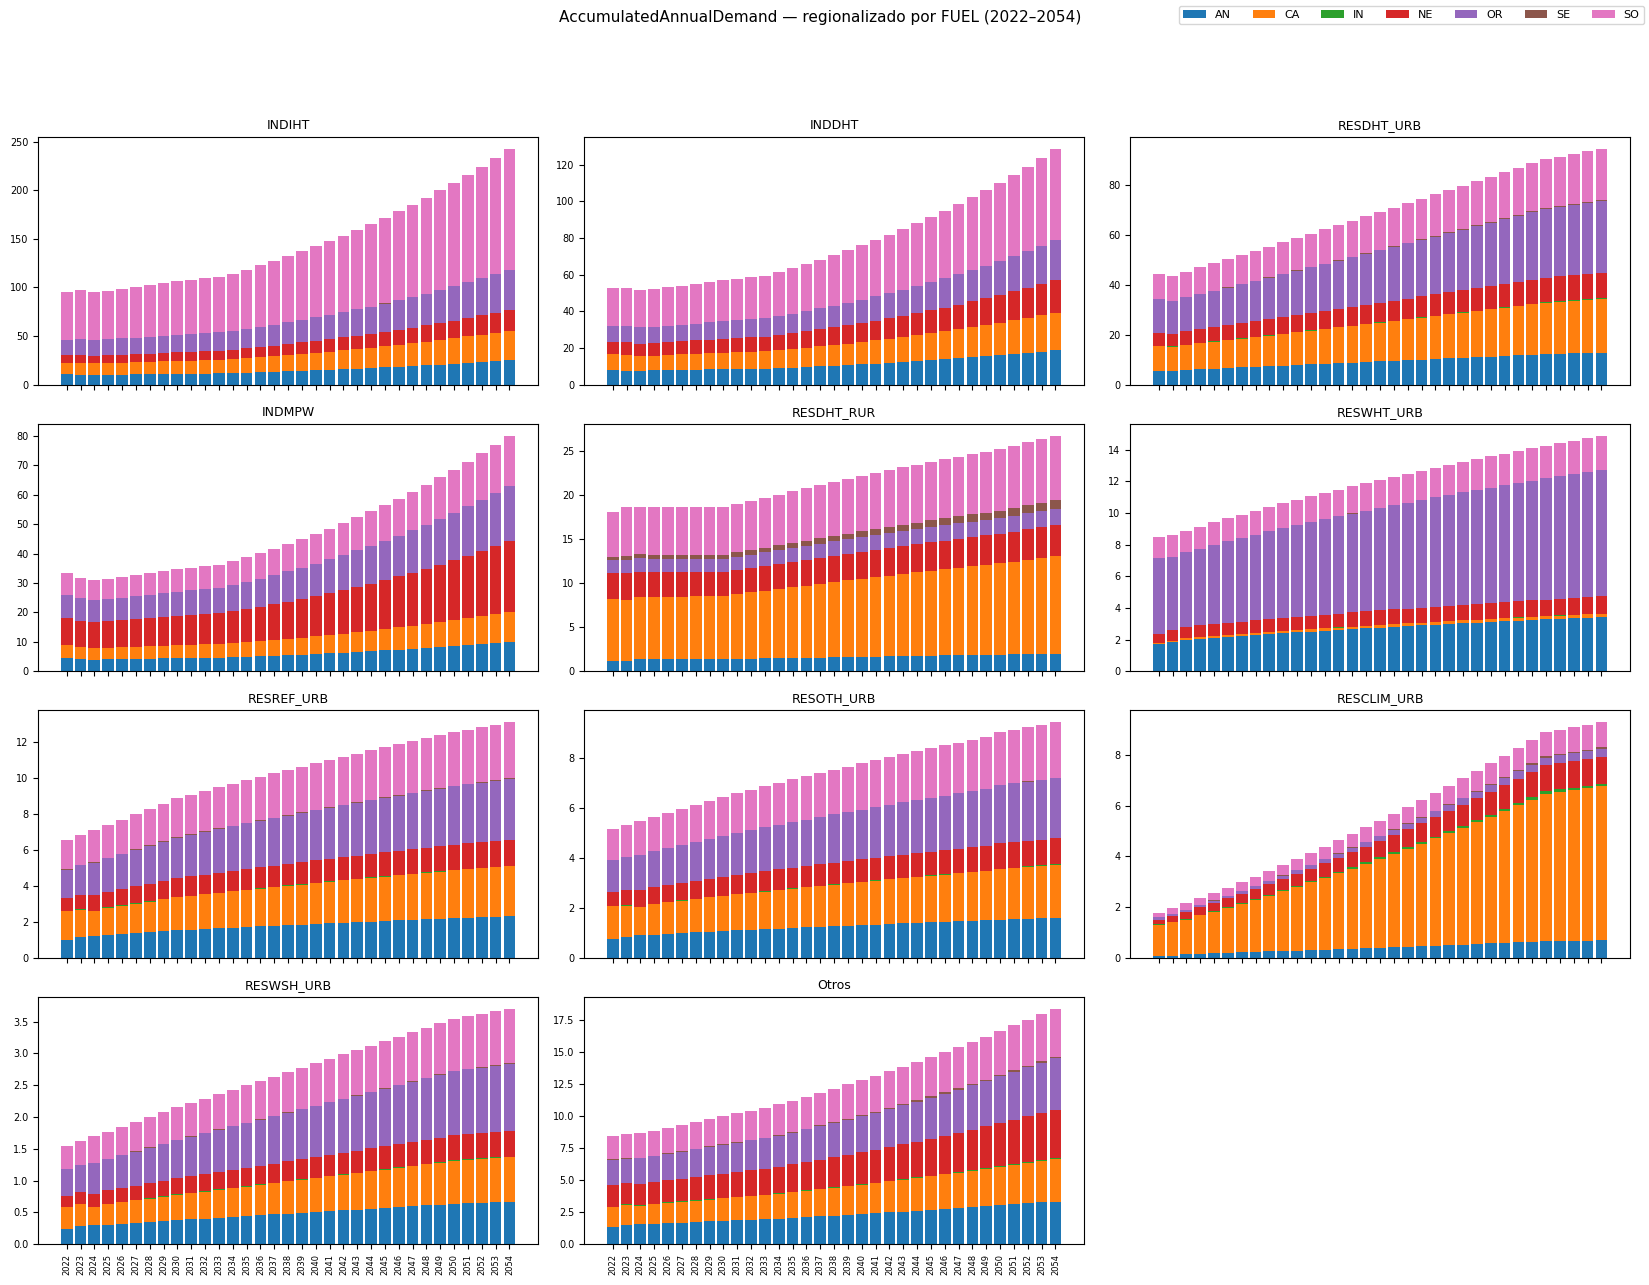

23:28:07 INFO    matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


23:28:07 INFO    matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


23:28:07 INFO    matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


23:28:07 INFO    matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


23:28:07 INFO    matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


...

23:28:09 INFO    matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


23:28:09 INFO    matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


23:28:09 INFO    matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


23:28:09 INFO    matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


23:28:09 INFO    matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


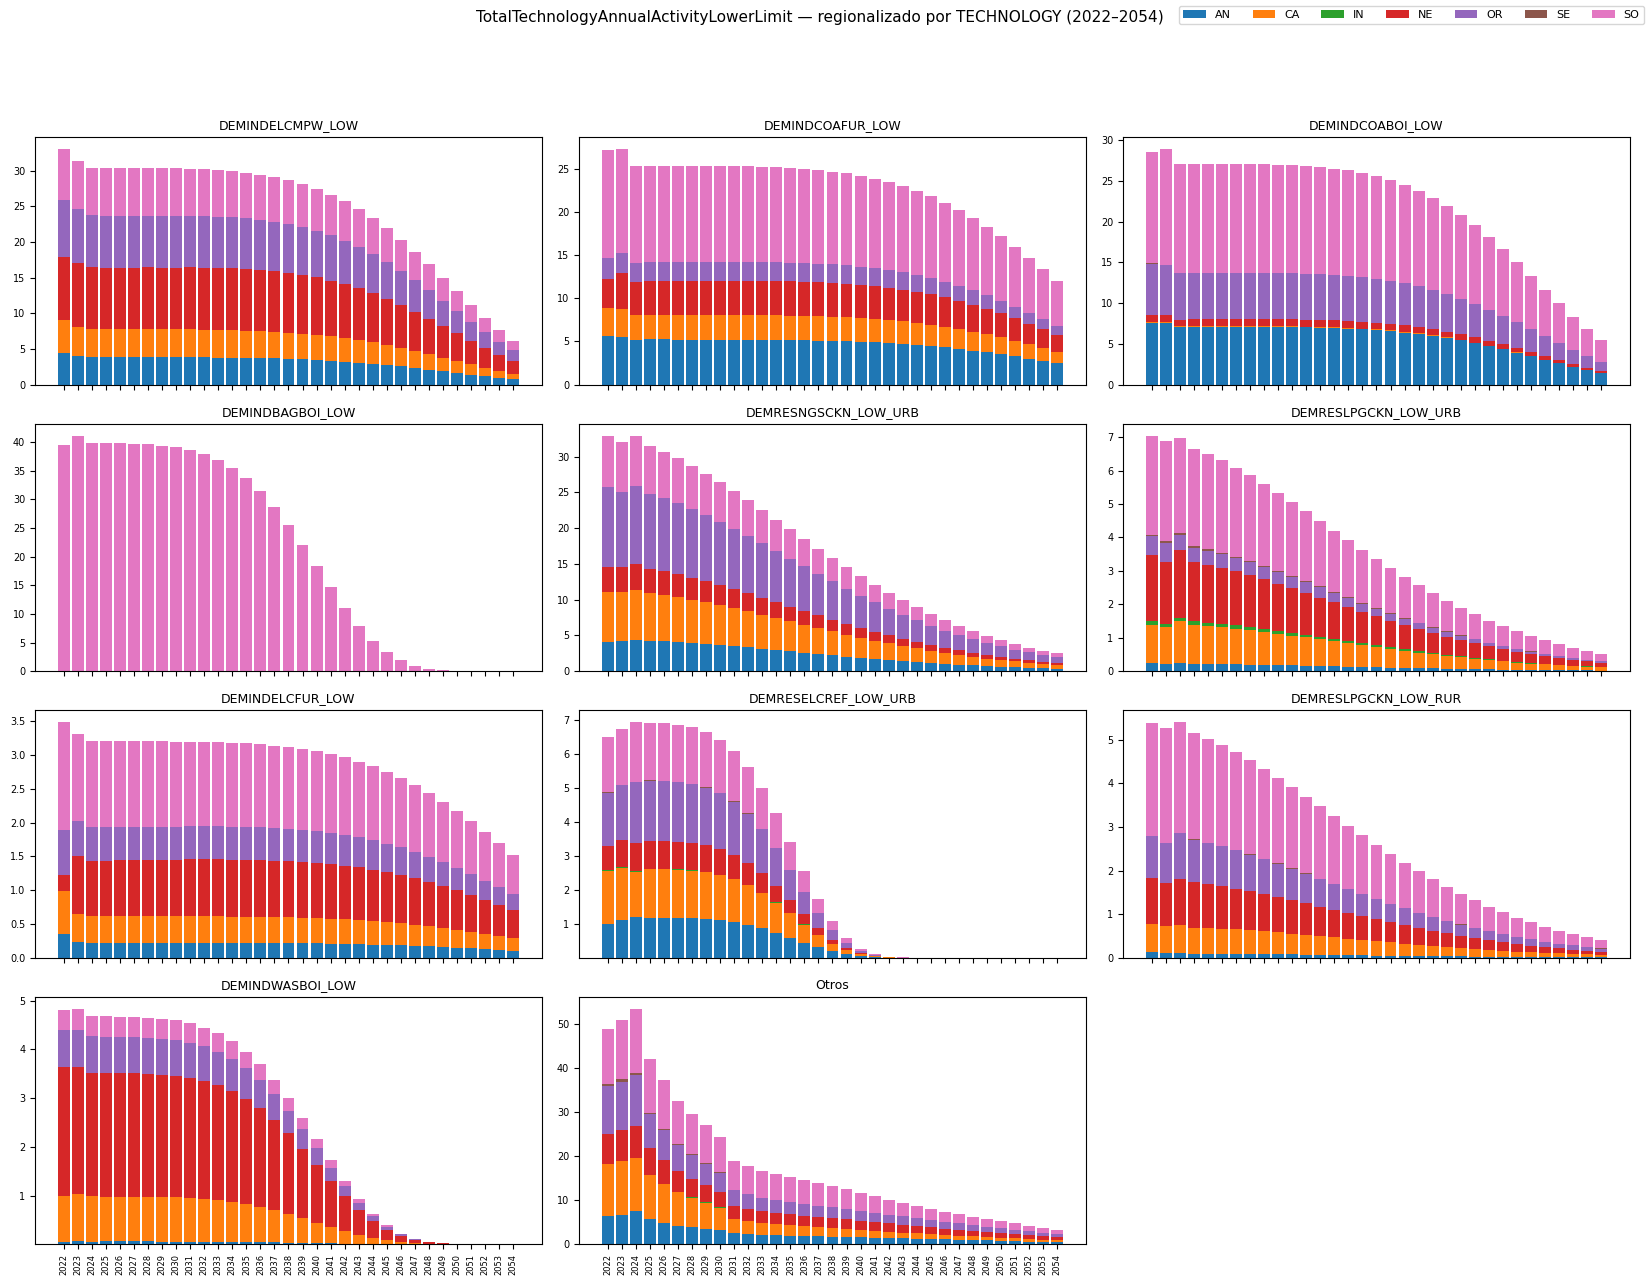

In [10]:
import matplotlib.pyplot as plt

for parametro in PARAMETROS_A_REGIONALIZAR:
    df_sand = sands.get(parametro)
    if df_sand is None or df_sand.empty:
        display(Markdown(
            f"⚠ **{parametro}** no tiene datos regionalizados — "
            f"revisar `{RUTA_OMISIONES.name}`"))
        continue
    fig = reporte.grafica_control_regionalizacion(
        df_sand, parametro, otoole["param"][parametro]["indices"],
        anios=[str(a) for a in YEARS_FILTRO],
    )
    if fig is None:
        display(Markdown(f"⚠ **{parametro}**: sin valores numéricos para graficar"))
    else:
        plt.show()

## 6. Exportar SANDs reducidos y log

In [11]:
if MODO_DRY_RUN:
    display(Markdown("**DRY-RUN — no se escribió ningún archivo.** Se habría generado:"))
    carpeta = paths["outputs"]["sands_reducidos"]
    if CONSOLIDADO:
        total = sum(len(d) for d in sands.values())
        print(f"  {carpeta / f'SAND_Consolidado_{DESCRIPCION}.xlsx'}  ({total:,} filas)")
    else:
        for parametro, df_sand in sands.items():
            print(f"  {carpeta / f'SAND_{parametro}_{DESCRIPCION}.xlsx'}  ({len(df_sand):,} filas)")
    print(f"  {paths['outputs']['reportes']}/log_regionalizacion_*.xlsx (+ .txt)")
    rutas_sand = []
else:
    rutas_sand = regionalizador.escribir_sands(
        sands, paths["outputs"]["sands_reducidos"], DESCRIPCION, consolidado=CONSOLIDADO,
    )
    for ruta in rutas_sand:
        print(f"SAND : {ruta}")

    # El log lleva adjuntas las decisiones de omisión finales
    log_completo = log.copy()
    ruta_log_xlsx, ruta_log_txt = reporte.escribir_log_regionalizacion(
        log_completo, paths["outputs"]["reportes"],
    )
    if not omisiones.empty:
        with pd.ExcelWriter(ruta_log_xlsx, engine="openpyxl", mode="a") as writer:
            omisiones.to_excel(writer, sheet_name="Omisiones", index=False)
    print(f"Log  : {ruta_log_xlsx}")
    print(f"Log  : {ruta_log_txt}")

**DRY-RUN — no se escribió ningún archivo.** Se habría generado:

  C:\Users\carlo\Documents\05_Gestion_Empresas\01_UPME\Proyectos\Generar_Escenario_Regional\SANDs_Reducidos\SAND_AccumulatedAnnualDemand_Mapeo.xlsx  (154 filas)
  C:\Users\carlo\Documents\05_Gestion_Empresas\01_UPME\Proyectos\Generar_Escenario_Regional\SANDs_Reducidos\SAND_TotalTechnologyAnnualActivityLowerLimit_Mapeo.xlsx  (987 filas)
  C:\Users\carlo\Documents\05_Gestion_Empresas\01_UPME\Proyectos\Generar_Escenario_Regional\reportes/log_regionalizacion_*.xlsx (+ .txt)


In [12]:
# --- Resumen final ---
pedidos = list(PARAMETROS_A_REGIONALIZAR)
con_datos = [p for p in pedidos if p in sands and not sands[p].empty]
parciales = [p for p in con_datos
             if not resumen.loc[resumen["Parametro"] == p, "Combos_Omitidos"].eq(0).all()]
vacios = [p for p in pedidos if p not in con_datos]
filas_totales = int(resumen["Filas_SAND"].sum()) if not resumen.empty else 0

display(Markdown("### Resumen final"))
print(f"Parámetros regionalizados exitosamente : {len(con_datos)}")
print(f"Parámetros con omisiones parciales     : {len(parciales)}"
      + (f" -> {parciales}" if parciales else ""))
print(f"Parámetros omitidos completamente      : {len(vacios)}"
      + (f" -> {vacios}" if vacios else ""))
print(f"Filas SAND generadas en total          : {filas_totales:,}")
if not omisiones.empty:
    creados = omisiones["Decision"].str.startswith(("crear_todas", "crear_regiones")).sum()
    print(f"Omisiones registradas                  : {len(omisiones)} "
          f"({creados} resueltas creando regiones)")
print("\nArchivos exportados:")
if MODO_DRY_RUN:
    print("  SANDs y log: ninguno (MODO_DRY_RUN = True)")
else:
    for ruta in rutas_sand:
        print(f"  {ruta}")
    print(f"  {ruta_log_xlsx}")
    print(f"  {ruta_log_txt}")
if not omisiones.empty:
    # La auditoría de omisiones se escribe siempre, también en dry-run
    print(f"  {RUTA_OMISIONES}  (auditoría, se escribe siempre)")

### Resumen final

Parámetros regionalizados exitosamente : 2
Parámetros con omisiones parciales     : 2 -> ['AccumulatedAnnualDemand', 'TotalTechnologyAnnualActivityLowerLimit']
Parámetros omitidos completamente      : 0
Filas SAND generadas en total          : 1,141
Omisiones registradas                  : 335 (0 resueltas creando regiones)

Archivos exportados:
  SANDs y log: ninguno (MODO_DRY_RUN = True)
  C:\Users\carlo\Documents\05_Gestion_Empresas\01_UPME\Proyectos\Generar_Escenario_Regional\reportes\omisiones_regionalizacion.xlsx  (auditoría, se escribe siempre)


## Siguiente paso

Integrar los SAND reducidos al escenario regional y convertirlo con otoole:

```bash
otoole convert csv excel CSV_Regional salida.xlsx config_depurado.yaml
```

*Smoke tests de los módulos: `python tests/test_smoke.py` desde la raíz del proyecto.*